# ACS 2024 Income Model — Training Notebook

A working scaffold derived from **`ML_Model_Building_Template.md`**, wired to **`acs2024_income.csv`** — the rich 18-feature ACS 2024 extract produced by `acs2024_income_extraction.ipynb`. Run top-to-bottom.

**Dataset:** `acs2024_income.csv` — 339,727 employed working-age adults, socio-economic predictors from the 2024 ACS PUMS (1-Year).

| Column | Meaning | Kind |
|---|---|---|
| `AGEP` | Age in years | continuous |
| `WKHP` | Usual hours worked per week | continuous |
| `WKWN` | Weeks worked in past 12 months | continuous |
| `COW` | Class of worker (employment sector) | categorical |
| `SCHL` | Education level (ordinal code) | categorical |
| `MAR` | Marital status | categorical |
| `OCCP` | Occupation code | categorical |
| `INDP` | Industry code | categorical |
| `POBP` | Place of birth | categorical |
| `RELSHIPP` | Relationship to householder | categorical |
| `SEX` | Sex | categorical |
| `RAC1P` | Race group | categorical |
| `HISP` | Hispanic origin | categorical |
| `CIT` | Citizenship status | categorical |
| `NATIVITY` | Nativity (native / foreign-born) | categorical |
| `ENG` | English-speaking ability | categorical |
| `DIS` | Disability | categorical |
| `ST` | State (FIPS code) | categorical |
| **`WAGP`** | **Target — wages/salary income (scaled)** | continuous |

| Stage | Name | Key concern |
|---|---|---|
| 1 | Environment Setup | Reproducibility |
| 2 | Data Loading & Preview | Understand structure & quality |
| 3 | Data Cleaning | Missing values -> encoding -> imbalance |
| 4 | Graphical EDA | Distributions & relationships |
| 5 | Feature Engineering | Identify -> generate -> select |
| 6 | Train / Val / Test Split | Stratified, no leakage |
| 7 | Feature Scaling | Fit on train only |
| 8 | Model Architecture | Algorithm choice & hyperparameters |
| 9 | Training | Cross-validation or epoch-based |
| 10 | Learning Curves | Diagnose over/underfitting |
| 11 | Evaluation | Training + test metrics |
| 12 | Save & Inference | Persistence & deployment |

> **Task type:** **regression** — predict `WAGP` from the remaining 18 features. The categorical columns are integer-coded ACS values (`OCCP`, `INDP`, `POBP`, `ST` are high-cardinality), which suits native-categorical gradient-boosted trees.
>
> **Models:** Stages 8-12 train **three boosted-tree learners side by side — CatBoost, XGBoost, LightGBM — under identical modifications** (Feature Gen w/ Select K-Best + Log-on-Target) for a like-for-like comparison.

## Stage 1 — Environment Setup & Library Imports

Import everything upfront, set display options so nothing is truncated, and fix a global seed for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=10000)

## Stage 2 — Data Loading & Textual Preview

Load `acs2024_income.csv` and inspect it textually: shape, head/tail, schema, summary stats, and target distribution. Note any data-quality problems to fix in Stage 3.

In [2]:
# Load dataset
dataset = pd.read_csv("acs2024_income.csv", header=0, index_col=None)

TARGET_COLUMN   = "WAGP"
FEATURE_COLUMNS = [c for c in dataset.columns if c != TARGET_COLUMN]
# Continuous vs. categorical (categoricals are integer-coded ACS values).
# OCCP, INDP, POBP, ST are high-cardinality -> prefer native-categorical models.
CONTINUOUS_COLS  = ["AGEP", "WKHP", "WKWN"]
CATEGORICAL_COLS = ["COW", "SCHL", "MAR", "OCCP", "INDP", "POBP", "RELSHIPP",
                    "SEX", "RAC1P", "HISP", "CIT", "NATIVITY", "ENG", "DIS", "ST"]

print("Shape:", dataset.shape, "\n")
print(dataset.head(), "\n")
print(dataset.tail(), "\n")

Shape: (339727, 19) 

   AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
0    46    40    52    3    20    5  5320  6770     6        25    1      8     2    1         1    1    2  48  0.034315
1    41    40    52    3    20    3  3655  9480    26        20    2      9     1    1         1    0    1  26  0.034519
2    33    45    52    1    19    5  5420  8191    51        22    2      1     1    1         1    0    2  51  0.040610
3    56    40    52    1    12    5  7315   770    13        20    1      1     1    1         1    0    2  13  0.051778
4    61    40    52    1    21    1  2635  7370    51        21    2      1     1    1         1    0    2  51  0.016244 

        AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
339722    33    35    52    1    19    1  6355   770    35        21    1      1     1    1         1    0    2  39  0.12183

<class 'pandas.DataFrame'>
RangeIndex: 339727 entries, 0 to 339726
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   AGEP      339727 non-null  int64  
 1   WKHP      339727 non-null  int64  
 2   WKWN      339727 non-null  int64  
 3   COW       339727 non-null  int64  
 4   SCHL      339727 non-null  int64  
 5   MAR       339727 non-null  int64  
 6   OCCP      339727 non-null  int64  
 7   INDP      339727 non-null  int64  
 8   POBP      339727 non-null  int64  
 9   RELSHIPP  339727 non-null  int64  
 10  SEX       339727 non-null  int64  
 11  RAC1P     339727 non-null  int64  
 12  HISP      339727 non-null  int64  
 13  CIT       339727 non-null  int64  
 14  NATIVITY  339727 non-null  int64  
 15  ENG       339727 non-null  int64  
 16  DIS       339727 non-null  int64  
 17  ST        339727 non-null  int64  
 18  WAGP      339727 non-null  float64
dtypes: float64(1), int64(18)
memory usage: 49.2 MB
None 

 

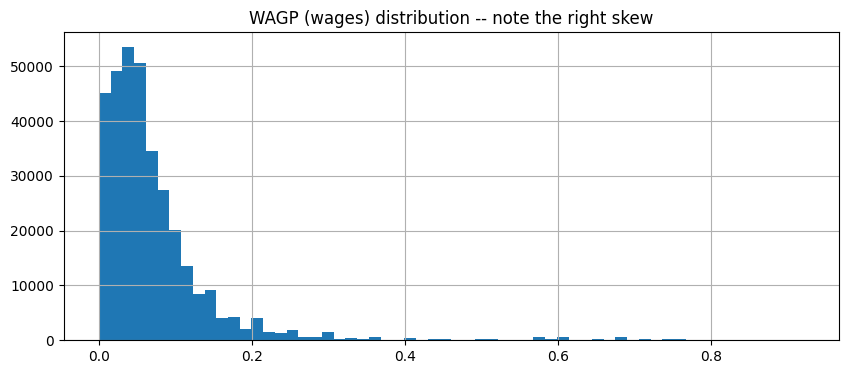

In [3]:
# Structure, dtypes, missing counts, summary stats
print(dataset.info(), "\n")
print(dataset.describe(), "\n")
print("Missing values per column:\n", dataset.isna().sum(), "\n")

# Cardinality of categorical columns (flags high-cardinality features for Stage 8)
print("Unique values per categorical column:")
print(dataset[CATEGORICAL_COLS].nunique().sort_values(ascending=False), "\n")

# Target distribution (regression -> describe + histogram)
print(dataset[TARGET_COLUMN].describe())
dataset[TARGET_COLUMN].hist(bins=60, figsize=(10, 4))
plt.title("WAGP (wages) distribution -- note the right skew"); plt.show()

### Stage 2 — Data-quality notes

- **Shape:** 339,727 rows x 19 columns (18 features + `WAGP` target).
- **No missing values:** the extraction step already filtered and sentinel-filled, so Stage 3a is a guard/no-op here.
- **Categoricals are integer-coded:** no string encoding needed. `OCCP`, `INDP`, `POBP`, and `ST` are high-cardinality (hundreds of levels) -> favour native-categorical learners (CatBoost / XGBoost / LightGBM) over one-hot.
- **Target `WAGP` is already scaled** to roughly `[0, 0.92]` (not raw dollars) and is **right-skewed** -> `log1p` transform in Stage 3d; metrics are converted back to dollars (x1e6) in Stage 11.

## Stage 3 — Data Cleaning & Problem Fixing

Fix problems **before** encoding/transformation, in the template order **missing values -> categorical encoding -> class imbalance**, plus a few dataset-specific checks. For `acs2024_income.csv` most template steps are guards/no-ops (no nulls, already integer-coded, regression target), so each cell below keeps the **recommended** path active and the **alternatives commented** so the full menu is visible.

**The menu**

| Sub-stage | Recommended (active) | Alternatives (commented) |
|---|---|---|
| 3a Missing values | guard (no nulls present) | KNN / median impute; sentinel level |
| 3b Categorical encoding | keep native, enforce `int` codes | one-hot (low-card only); ordinal (`SCHL`/`ENG`); frequency/target encode (high-card); coarsen to ACS rollups |
| 3c Class imbalance | N/A (continuous target) | bracket `WAGP` + SMOTE/undersample (classification variant) |
| 3d Dataset-specific | duplicate check; `log1p` target | winsorize top-coded tail |

In [4]:
# 3a -- Missing values. acs2024_income.csv has NONE, so this is a guard/no-op.
# (The extractor already sentinel-filled non-applicable OCCP/INDP with -1, i.e.
#  "no occupation/industry" is its own category rather than a NaN.)
from sklearn.impute import KNNImputer

cols_with_nulls = [c for c in dataset.columns if dataset[c].isna().any()]
if cols_with_nulls:
    cont_nulls = [c for c in cols_with_nulls if c in CONTINUOUS_COLS]
    cat_nulls  = [c for c in cols_with_nulls if c in CATEGORICAL_COLS]
    if cont_nulls:                                   # continuous -> KNN (or median)
        dataset[cont_nulls] = KNNImputer(n_neighbors=5).fit_transform(dataset[cont_nulls])
    for c in cat_nulls:                              # categorical -> dedicated sentinel
        dataset[c] = dataset[c].fillna(-1)

print("Columns with nulls:", cols_with_nulls)
print("Remaining missing values:", int(dataset.isna().sum().sum()))

Columns with nulls: []
Remaining missing values: 0


In [5]:
# 3b -- Categorical handling. Columns are ALREADY integer-coded ACS values, so no
# string encoding is needed; the real decision is how DOWNSTREAM models treat them.
HIGH_CARD = ["OCCP", "INDP", "POBP", "ST"]                 # 525 / 257 / 222 / 51 levels
LOW_CARD  = [c for c in CATEGORICAL_COLS if c not in HIGH_CARD]

# === RECOMMENDED: keep native categorical, just enforce integer codes ==========
# CatBoost consumes these directly via cat_features; XGBoost/LightGBM via category dtype.
for c in CATEGORICAL_COLS:
    dataset[c] = dataset[c].astype(int)
print("Categoricals enforced as int. High-cardinality levels:",
      {c: int(dataset[c].nunique()) for c in HIGH_CARD})

# === ALTERNATIVE 1 -- One-hot the LOW-cardinality columns only =================
# Good for linear / distance models. NEVER one-hot OCCP/INDP/POBP (-> 1000+ cols).
# dataset = pd.get_dummies(dataset, columns=LOW_CARD, drop_first=True)

# === ALTERNATIVE 2 -- Ordinal encode the genuinely ORDERED columns =============
# Only SCHL (education) and ENG (English ability) have a meaningful order; they are
# already monotonic codes, so use this only if starting from raw string categories.
# from sklearn.preprocessing import OrdinalEncoder
# dataset[["SCHL", "ENG"]] = OrdinalEncoder().fit_transform(dataset[["SCHL", "ENG"]])

# === ALTERNATIVE 3 -- Frequency / target encoding for HIGH-cardinality =========
# For models WITHOUT native categorical support (sklearn RF, linear). Frequency
# encoding is leak-free; target encoding MUST be fit inside CV folds (Stage 6+).
# for c in HIGH_CARD:
#     dataset[c + "_freq"] = dataset[c].map(dataset[c].value_counts(normalize=True))

# === ALTERNATIVE 4 -- Coarsen high-cardinality codes to ACS rollups ============
# dataset["OCCP_grp"] = (dataset["OCCP"] // 100).astype(int)    # ~major occ groups
# dataset["INDP_grp"] = (dataset["INDP"] // 1000).astype(int)   # ~sectors

Categoricals enforced as int. High-cardinality levels: {'OCCP': 525, 'INDP': 257, 'POBP': 222, 'ST': 51}


In [6]:
# 3c -- Class imbalance: NOT APPLICABLE (WAGP is a continuous regression target).
# Only relevant for a CLASSIFICATION variant where WAGP is binned into brackets:
# brackets = pd.qcut(dataset[TARGET_COLUMN], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
# then rebalance the resulting classes (SVMSMOTE / RandomUnderSampler).
print("Regression target -- no resampling applied.")

Regression target -- no resampling applied.


In [7]:
# 3d -- Dataset-specific checks beyond the template.

# Duplicate rows: PUMS can legitimately repeat identical feature rows -> inspect, keep.
print("Exact duplicate rows:", int(dataset.duplicated().sum()))

# Outliers / top-coding: Census top-codes very high wages, compressing the right tail.
# WAGP here is already scaled to ~[0, 0.92]. OPTIONAL winsorize at the 99.5th pct:
# cap = dataset[TARGET_COLUMN].quantile(0.995)
# dataset[TARGET_COLUMN] = dataset[TARGET_COLUMN].clip(upper=cap)

# Target transform (right-skew): build a log1p target as a SEPARATE series (do NOT
# add it as a feature column). Invert with expm1 before reporting metrics in Stage 11.
y_log = np.log1p(dataset[TARGET_COLUMN])
print("\nlog1p(WAGP) summary:")
print(y_log.describe())

Exact duplicate rows: 1352

log1p(WAGP) summary:
count    339727.000000
mean          0.068582
std           0.068556
min           0.000004
25%           0.030003
50%           0.051447
75%           0.087436
max           0.652758
Name: WAGP, dtype: float64


## Stage 4 — Graphical Data Exploration (EDA)

Visualise distributions and relationships before engineering features. The skewed continuous histograms justify the target transform; the grouped-median bars and the focused scatter confirm the headline socio-economic signal (education, hours, sex) is present.

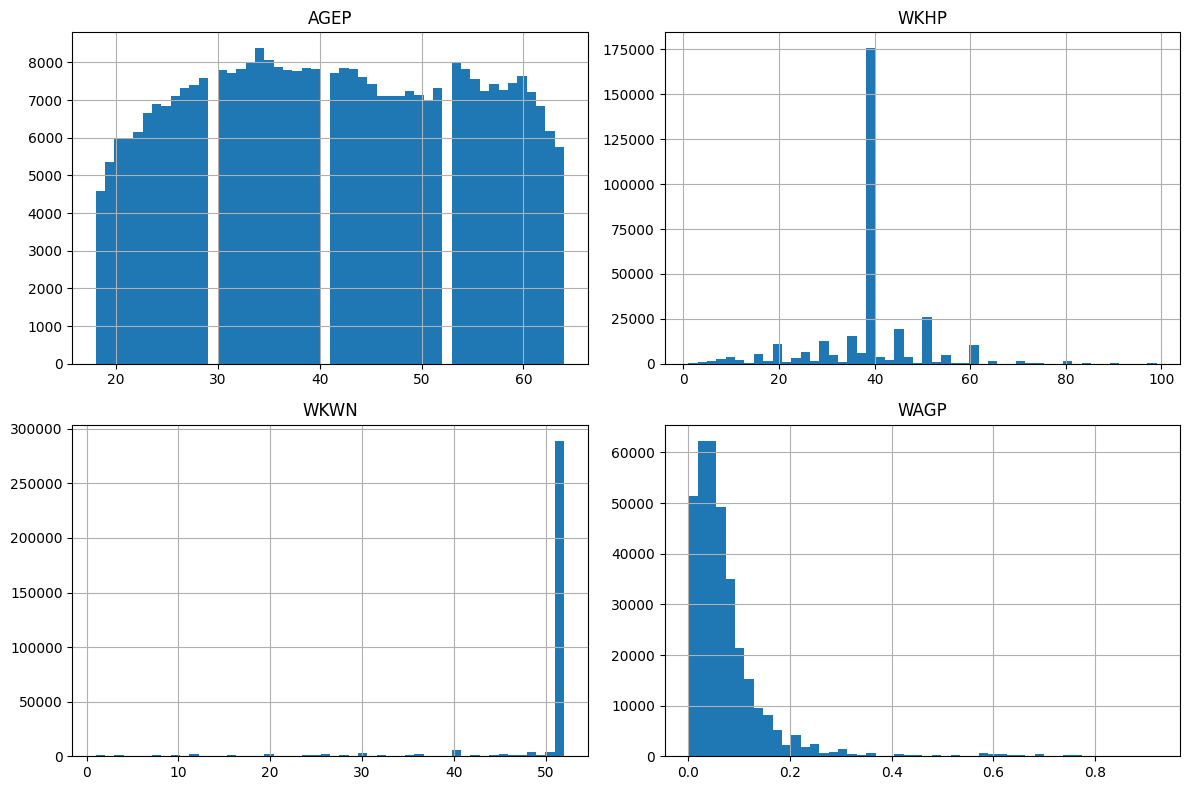

In [8]:
# Distribution of the continuous features + target. (Categorical columns are integer
# CODES, so a numeric histogram of them is not meaningful -- a few key ones are shown
# as grouped medians below instead.)
dataset[CONTINUOUS_COLS + [TARGET_COLUMN]].hist(bins=50, figsize=(12, 8))
plt.tight_layout(); plt.show()

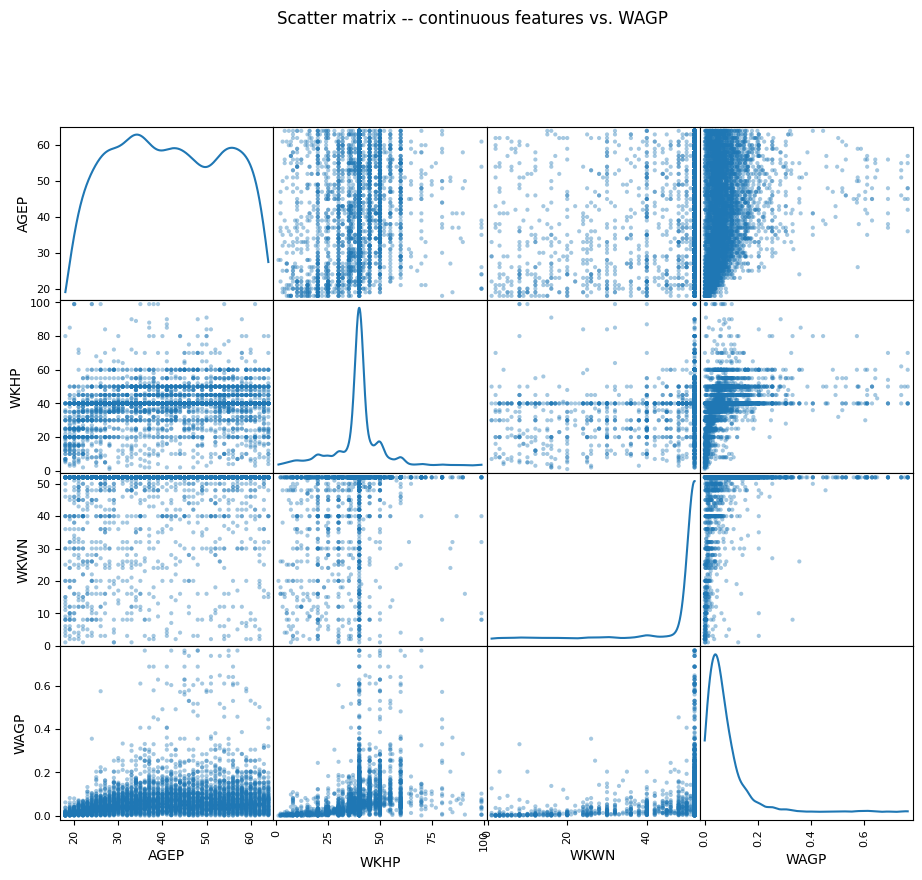

In [9]:
# Pairwise scatter matrix on the continuous features + target (sampled for speed).
from pandas.plotting import scatter_matrix

attrs = CONTINUOUS_COLS + [TARGET_COLUMN]
scatter_matrix(dataset[attrs].sample(5000, random_state=RANDOM_STATE),
               alpha=0.4, figsize=(11, 9), diagonal="kde")
plt.suptitle("Scatter matrix -- continuous features vs. WAGP", y=1.01); plt.show()

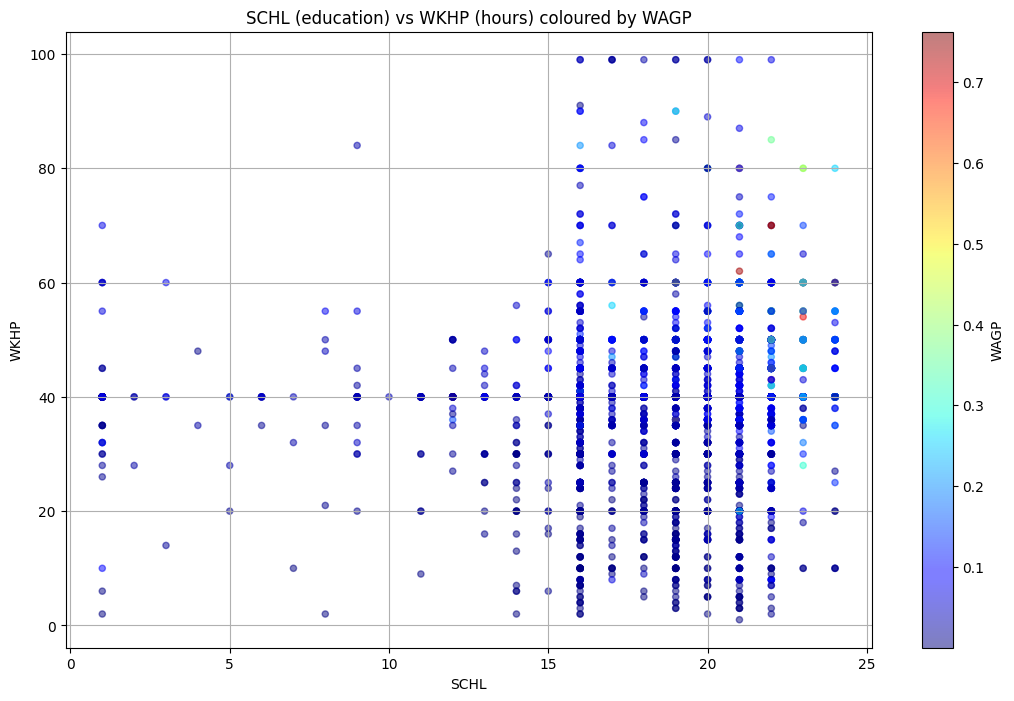

In [10]:
# Focused scatter: education vs. usual hours worked, coloured by wage.
dataset.sample(5000, random_state=RANDOM_STATE).plot(
    kind="scatter", x="SCHL", y="WKHP", c=TARGET_COLUMN, cmap="jet",
    colorbar=True, grid=True, figsize=(13, 8), alpha=0.5)
plt.title("SCHL (education) vs WKHP (hours) coloured by WAGP"); plt.show()

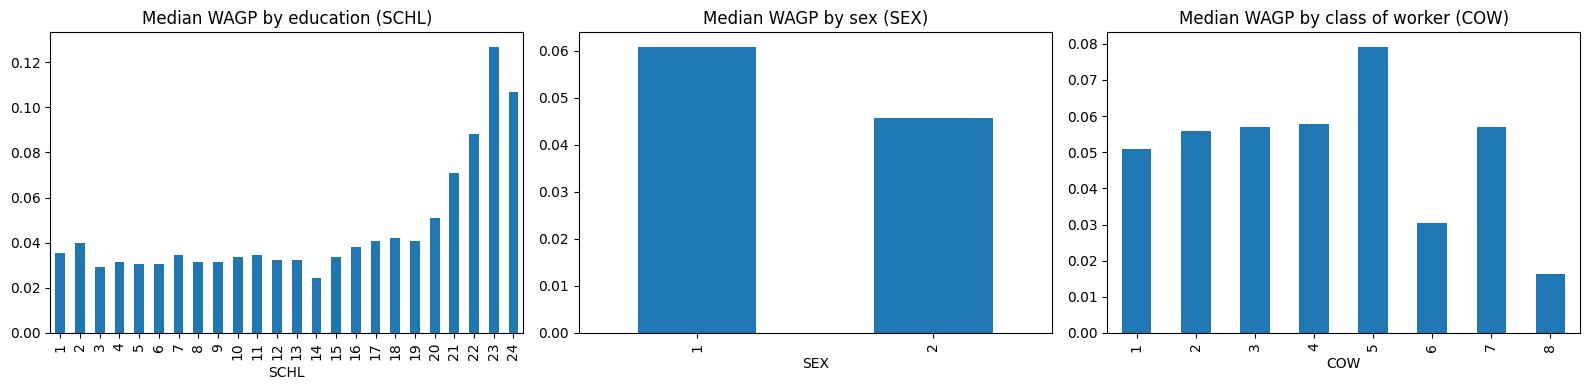

In [11]:
# Signal check: median wage by a few key categoricals (codes ordered on the x-axis).
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
dataset.groupby("SCHL")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[0])
ax[0].set_title("Median WAGP by education (SCHL)")
dataset.groupby("SEX")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[1])
ax[1].set_title("Median WAGP by sex (SEX)")
dataset.groupby("COW")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[2])
ax[2].set_title("Median WAGP by class of worker (COW)")
plt.tight_layout(); plt.show()

## Stage 5 — Feature Engineering

**Identify** features vs. target -> **generate** more expressive features -> **select** the non-redundant subset.

Selection uses **mutual information** (captures non-linear + categorical relationships, unlike Pearson) to rank every feature against `log1p(WAGP)`. The **correlation heatmap** in 5c is run on the *numeric* features only (continuous + generated + target), where Pearson is meaningful — its job is to expose collinearity between generated interaction terms and their parent columns. Nominal high-cardinality codes are left out of the heatmap because correlation between arbitrary code numbers is not interpretable.

In [12]:
# 5a -- Feature identification. Use the log1p target from Stage 3d for SELECTION
# scoring (tames skew); keep raw WAGP in trgt_y for dollar-scale reporting later.
feats_X = dataset[FEATURE_COLUMNS].copy()
trgt_y  = pd.DataFrame(dataset[[TARGET_COLUMN]])
y_sel   = y_log                                  # built in Stage 3d
print("feats_X:", feats_X.shape, "| trgt_y:", trgt_y.shape)

feats_X: (339727, 18) | trgt_y: (339727, 1)


In [13]:
# 5b -- Feature generation. Domain-motivated interactions for wages.
feats_X["ANNUAL_HOURS"] = feats_X["WKHP"] * feats_X["WKWN"]   # hours/wk x weeks worked
feats_X["AGEPxSCHL"]    = feats_X["AGEP"] * feats_X["SCHL"]   # experience x education
feats_X["WKHPxSCHL"]    = feats_X["WKHP"] * feats_X["SCHL"]   # effort x education
GENERATED_COLS = ["ANNUAL_HOURS", "AGEPxSCHL", "WKHPxSCHL"]

# Sanity check for inf / NaN introduced by the new features
check = feats_X[CONTINUOUS_COLS + GENERATED_COLS].values
indices = np.where(np.isinf(check) | np.isnan(check))
print("'NaN' or 'inf' indices:", list(zip(*indices)))
print("Added features:", GENERATED_COLS, "| feats_X now:", feats_X.shape)

'NaN' or 'inf' indices: []
Added features: ['ANNUAL_HOURS', 'AGEPxSCHL', 'WKHPxSCHL'] | feats_X now: (339727, 21)


In [14]:
# 5c -- Feature selection via mutual information (non-linear + categorical aware).
# Trees tolerate weak features, so we RANK all of them for insight and keep the top K;
# the heatmap below is what actually drives dropping redundant generated columns.
from sklearn.feature_selection import SelectKBest, mutual_info_regression

ALL_FEATURES  = list(feats_X.columns)
discrete_mask = [c in CATEGORICAL_COLS for c in ALL_FEATURES]   # generated cols -> continuous

# mutual_info is expensive on 340k rows -> score on a representative sample.
samp = feats_X.sample(min(20000, len(feats_X)), random_state=RANDOM_STATE)
K = 12
KBest = SelectKBest(
    score_func=lambda X, y: mutual_info_regression(
        X, y, discrete_features=discrete_mask, random_state=RANDOM_STATE),
    k=K)
KBest.fit(samp, y_sel.loc[samp.index])

mi_scores = pd.Series(KBest.scores_, index=ALL_FEATURES).sort_values(ascending=False)
selected  = list(KBest.get_feature_names_out())
print("Mutual information with log(WAGP):\n", mi_scores.round(4), "\n")
print(f"Top {K} selected:", selected)
top_feats_X = feats_X[selected]

Mutual information with log(WAGP):
 OCCP            0.3393
WKHPxSCHL       0.3107
ANNUAL_HOURS    0.3043
WKHP            0.2282
INDP            0.1857
AGEPxSCHL       0.1673
SCHL            0.1347
WKWN            0.1331
RELSHIPP        0.1110
AGEP            0.1081
MAR             0.0582
ST              0.0538
COW             0.0320
POBP            0.0275
RAC1P           0.0236
HISP            0.0177
ENG             0.0126
CIT             0.0120
SEX             0.0102
NATIVITY        0.0057
DIS             0.0041
dtype: float64 

Top 12 selected: ['AGEP', 'WKHP', 'WKWN', 'SCHL', 'MAR', 'OCCP', 'INDP', 'RELSHIPP', 'ST', 'ANNUAL_HOURS', 'AGEPxSCHL', 'WKHPxSCHL']


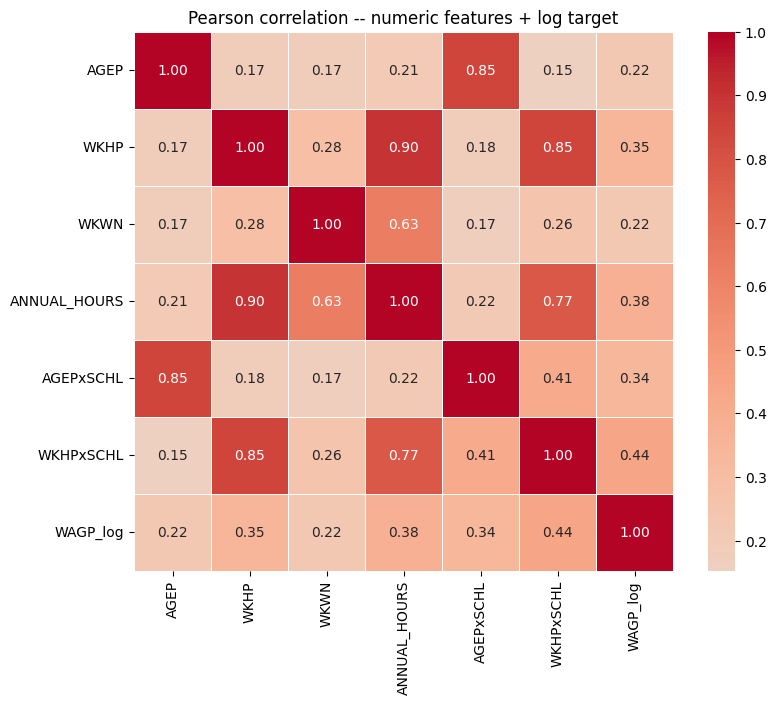

In [15]:
# 5c (heatmap) -- multicollinearity check on the NUMERIC features + target only.
# Pearson is meaningful here; spikes flag redundancy (e.g. ANNUAL_HOURS vs WKHP/WKWN).
numeric_cols = CONTINUOUS_COLS + GENERATED_COLS
corr = pd.concat([feats_X[numeric_cols], y_log.rename("WAGP_log")], axis=1).corr("pearson")

plt.figure(figsize=(9, 7))
sbn.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Pearson correlation -- numeric features + log target"); plt.show()

In [16]:
# Finalise the non-redundant feature set. Generated interactions are collinear with
# their parents (see heatmap): for TREES that is harmless, so we keep the full set.
useful_feats_X = feats_X[selected].copy()
print("Final feature set:", list(useful_feats_X.columns))
print("useful_feats_X:", useful_feats_X.shape)

Final feature set: ['AGEP', 'WKHP', 'WKWN', 'SCHL', 'MAR', 'OCCP', 'INDP', 'RELSHIPP', 'ST', 'ANNUAL_HOURS', 'AGEPxSCHL', 'WKHPxSCHL']
useful_feats_X: (339727, 12)


## Stage 6 — Train / Validation / Test Split

Regression target -> a plain shuffled `train_test_split` (an optional `qcut`-bin stratification is shown to balance income *ranges*). A validation slice is carved from train for early stopping. Targets are `log1p(WAGP)`; the `*_raw` series recover the (scaled) WAGP axis via `expm1`, then Stage 11 multiplies by 1e6 for dollars.

In [17]:
from sklearn.model_selection import train_test_split

X = useful_feats_X
y = y_sel                                   # = y_log, index-aligned with X

# Categorical subset that survived selection -> native categorical handling in Stage 8.
CAT_FEATURES = [c for c in X.columns if c in CATEGORICAL_COLS]
print("Categorical features carried into the models:", CAT_FEATURES)

# Primary 80/20 train-test split (shuffled).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Optional: balance income RANGES across splits instead (uncomment to stratify):
# strat_bins = pd.qcut(y, q=10, labels=False)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=strat_bins)

# Carve a validation slice out of train (early stopping).
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Raw-axis targets aligned to each split (expm1 inverts the log1p), for Stage 11.
y_train_raw = np.expm1(y_train)
y_val_raw   = np.expm1(y_val)
y_test_raw  = np.expm1(y_test)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

Categorical features carried into the models: ['SCHL', 'MAR', 'OCCP', 'INDP', 'RELSHIPP', 'ST']


X_train: (217424, 12) | X_val: (54357, 12) | X_test: (67946, 12)


## Stage 7 — Feature Scaling / Normalisation

**Primary (tree) path: no scaling.** Gradient-boosted trees are scale-invariant, the target is already `log1p`-transformed, and scaling would corrupt the integer category codes. The commented **DL / linear branch** shows the leakage-safe pattern: fit on **train only**, transform **numeric features only**.

In [18]:
from sklearn.preprocessing import QuantileTransformer, StandardScaler

# === PRIMARY (tree) path: NO scaling -- pass through ===========================
X_train_sc, X_val_sc, X_test_sc = X_train, X_val, X_test
y_train_sc, y_val_sc, y_test_sc = y_train, y_val, y_test
print("Tree path: features passed through unscaled.")

# === ALTERNATIVE (DL / linear branch): scale NUMERIC features only =============
# NUMERIC_COLS = [c for c in X_train.columns if c not in CAT_FEATURES]
# scaler_X = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE)
# scaler_X.fit(X_train[NUMERIC_COLS])
# def _scale(df):
#     out = df.copy(); out[NUMERIC_COLS] = scaler_X.transform(df[NUMERIC_COLS]); return out
# X_train_sc, X_val_sc, X_test_sc = _scale(X_train), _scale(X_val), _scale(X_test)

Tree path: features passed through unscaled.


## Stage 8 — Model Selection, Architecture & Compilation

Three boosted-tree regressors are configured **with matched hyperparameters** (`~2000` trees, `lr=0.05`, `max_depth=8`, L2 regularisation, early stopping) so differences reflect the *algorithm*, not the tuning. All three ingest the categoricals natively — including high-cardinality `OCCP`/`INDP`/`ST` — with no encoding:

- **CatBoost** — `cat_features` (ordered boosting, strong on high-cardinality).
- **XGBoost** — `enable_categorical=True` (needs pandas `category` dtype).
- **LightGBM** — `categorical_feature=` (needs pandas `category` dtype).

In [19]:
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

cat_model = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=10,
    loss_function="RMSE", eval_metric="RMSE", random_state=RANDOM_STATE,
    early_stopping_rounds=100, verbose=400)

xgb_model = XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=10, tree_method="hist",
    enable_categorical=True, early_stopping_rounds=100,
    random_state=RANDOM_STATE, verbosity=0)

lgb_model = LGBMRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=10,
    random_state=RANDOM_STATE, verbose=-1)

print("Configured CatBoost, XGBoost, LightGBM.")
print("Categorical features:", CAT_FEATURES)

Configured CatBoost, XGBoost, LightGBM.
Categorical features: ['SCHL', 'MAR', 'OCCP', 'INDP', 'RELSHIPP', 'ST']


## Stage 9 — Training

Each model trains on the `log1p` target with early stopping against the validation split. CatBoost takes the integer-coded frames via `Pool`; XGBoost/LightGBM take **`category`-dtype copies** of the same frames (built once below). Predictions later use whichever frame a model was trained on.

In [20]:
import time, lightgbm as lgb

# Category-dtype copies for XGBoost / LightGBM (integer levels -> pandas category).
def as_category(df):
    out = df.copy()
    for c in CAT_FEATURES:
        out[c] = out[c].astype("category")
    return out
X_train_cat, X_val_cat, X_test_cat = as_category(X_train), as_category(X_val), as_category(X_test)

# --- CatBoost (native Pool) ---
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
val_pool   = Pool(X_val,   y_val,   cat_features=CAT_FEATURES)
t0 = time.time(); cat_model.fit(train_pool, eval_set=val_pool)
print(f"CatBoost  trained {time.time()-t0:5.1f}s | best_iter {cat_model.get_best_iteration()}")

# --- XGBoost ---
t0 = time.time(); xgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], verbose=False)
print(f"XGBoost   trained {time.time()-t0:5.1f}s | best_iter {xgb_model.best_iteration}")

# --- LightGBM ---
t0 = time.time()
lgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], eval_metric="rmse",
              categorical_feature=CAT_FEATURES,
              callbacks=[lgb.early_stopping(100, verbose=False)])
print(f"LightGBM  trained {time.time()-t0:5.1f}s | best_iter {lgb_model.best_iteration_}")

# Map each model to the frames it predicts on (Stage 11).
MODELS = {
    "CatBoost": (cat_model, X_train,     X_test),
    "XGBoost":  (xgb_model, X_train_cat, X_test_cat),
    "LightGBM": (lgb_model, X_train_cat, X_test_cat),
}

0:	learn: 0.0676322	test: 0.0658714	best: 0.0658714 (0)	total: 229ms	remaining: 7m 38s


400:	learn: 0.0483300	test: 0.0474107	best: 0.0474107 (400)	total: 31.4s	remaining: 2m 5s


800:	learn: 0.0474380	test: 0.0471481	best: 0.0471481 (800)	total: 1m 4s	remaining: 1m 36s


1200:	learn: 0.0467190	test: 0.0470339	best: 0.0470337 (1199)	total: 1m 40s	remaining: 1m 6s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.04698950531
bestIteration = 1439

Shrink model to first 1440 iterations.
CatBoost  trained 138.8s | best_iter 1439


XGBoost   trained   1.4s | best_iter 106


LightGBM  trained   1.2s | best_iter 329


## Stage 10 — Learning Curve Visualisation

Left: CatBoost **train vs. validation** RMSE (the template's over/underfit diagnosis — a widening gap signals overfitting). Right: **validation RMSE for all three algorithms** overlaid, so their convergence and early-stopping points are directly comparable. All curves are on the `log1p` target axis.

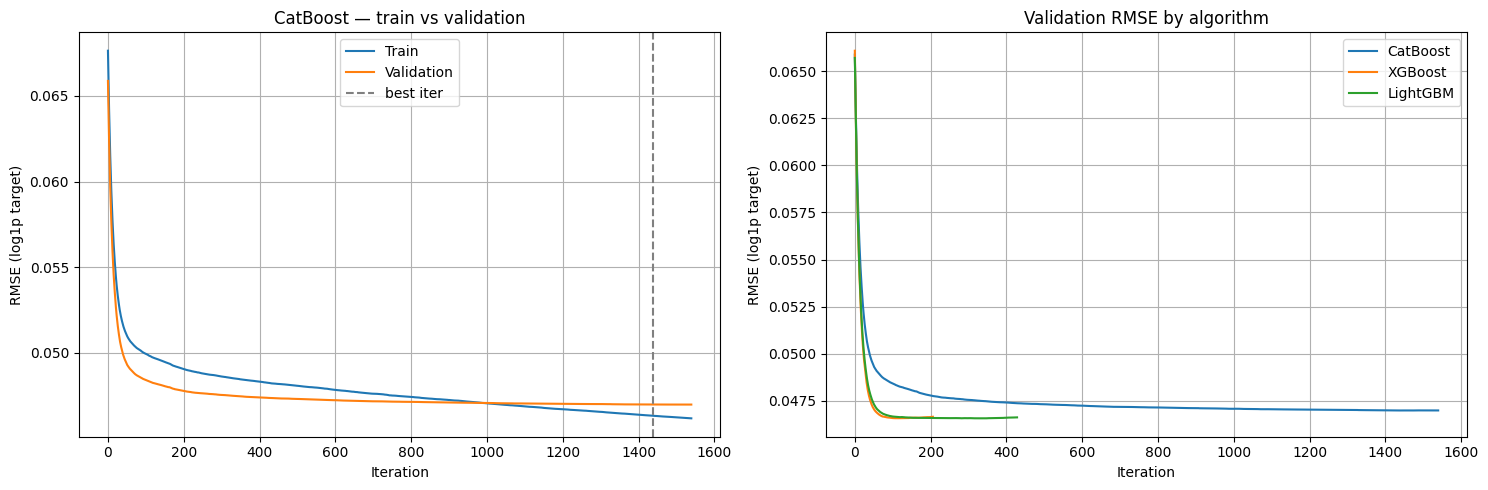

In [21]:
ev_cat = cat_model.get_evals_result()
ev_xgb = xgb_model.evals_result()
ev_lgb = lgb_model.evals_result_

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: CatBoost train vs validation
ax[0].plot(ev_cat["learn"]["RMSE"], label="Train")
ax[0].plot(ev_cat["validation"]["RMSE"], label="Validation")
ax[0].axvline(cat_model.get_best_iteration(), ls="--", c="grey", label="best iter")
ax[0].set_title("CatBoost — train vs validation")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("RMSE (log1p target)")
ax[0].legend(); ax[0].grid()

# Right: validation RMSE overlay across the three algorithms
ax[1].plot(ev_cat["validation"]["RMSE"],   label="CatBoost")
ax[1].plot(ev_xgb["validation_0"]["rmse"], label="XGBoost")
ax[1].plot(ev_lgb["valid_0"]["rmse"],      label="LightGBM")
ax[1].set_title("Validation RMSE by algorithm")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("RMSE (log1p target)")
ax[1].legend(); ax[1].grid()

plt.tight_layout(); plt.show()

## Stage 11 — Evaluation on Training & Test Sets

Score every model on **both** train and test so the train-vs-test gap is visible. Predictions are made on the `log1p` axis, inverted with `expm1`, then multiplied by `WAGP_TO_DOLLARS = 1e6` to report **MAE / RMSE in dollars** (the extractor stored `WAGP` as adjusted dollars / 1e6). `R²` / Explained Variance are scale-free. The printed rows match the Experiment-Log format; `results_df` collects them.

In [22]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             explained_variance_score, r2_score)

WAGP_TO_DOLLARS = 1_000_000
MODS = "Feature Gen w/ Select K-Best + Log-on-Target"

rows = []
print("| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |")
print("|---|---|---|---|---|---|---|---|")
for name, (m, X_tr, X_te) in MODELS.items():
    p_tr = np.expm1(m.predict(X_tr)) * WAGP_TO_DOLLARS
    p_te = np.expm1(m.predict(X_te)) * WAGP_TO_DOLLARS
    yt_tr = y_train_raw.values * WAGP_TO_DOLLARS
    yt_te = y_test_raw.values  * WAGP_TO_DOLLARS
    row = {
        "Algorithm": name, "Modifications": MODS,
        "Train MAE":  mean_absolute_error(yt_tr, p_tr),
        "Train RMSE": mean_squared_error(yt_tr, p_tr) ** 0.5,
        "Train R2":   r2_score(yt_tr, p_tr),
        "Test MAE":   mean_absolute_error(yt_te, p_te),
        "Test RMSE":  mean_squared_error(yt_te, p_te) ** 0.5,
        "Test R2":    r2_score(yt_te, p_te),
    }
    rows.append(row)
    print(f"| {name} | {MODS} | {row['Train MAE']:,.2f} | {row['Train RMSE']:,.2f} | "
          f"{row['Train R2']:.2f} | {row['Test MAE']:,.2f} | {row['Test RMSE']:,.2f} | {row['Test R2']:.2f} |")

results_df = pd.DataFrame(rows).sort_values("Test R2", ascending=False).reset_index(drop=True)
results_df

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|


| CatBoost | Feature Gen w/ Select K-Best + Log-on-Target | 28,299.89 | 58,953.75 | 0.51 | 28,966.74 | 60,025.18 | 0.47 |
| XGBoost | Feature Gen w/ Select K-Best + Log-on-Target | 26,186.46 | 54,322.86 | 0.58 | 28,550.22 | 59,295.54 | 0.49 |


| LightGBM | Feature Gen w/ Select K-Best + Log-on-Target | 26,467.84 | 54,269.41 | 0.58 | 28,634.62 | 59,237.01 | 0.49 |


,Algorithm,Modifications,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,LightGBM,Feature Gen w/ Select K-Best + Log-on-Target,26467.841418,54269.408142,0.580765,28634.620813,59237.009163,0.488041
1,XGBoost,Feature Gen w/ Select K-Best + Log-on-Target,26186.457549,54322.857946,0.579939,28550.222027,59295.541067,0.487028
2,CatBoost,Feature Gen w/ Select K-Best + Log-on-Target,28299.894820,58953.754658,0.505268,28966.736137,60025.184225,0.474326


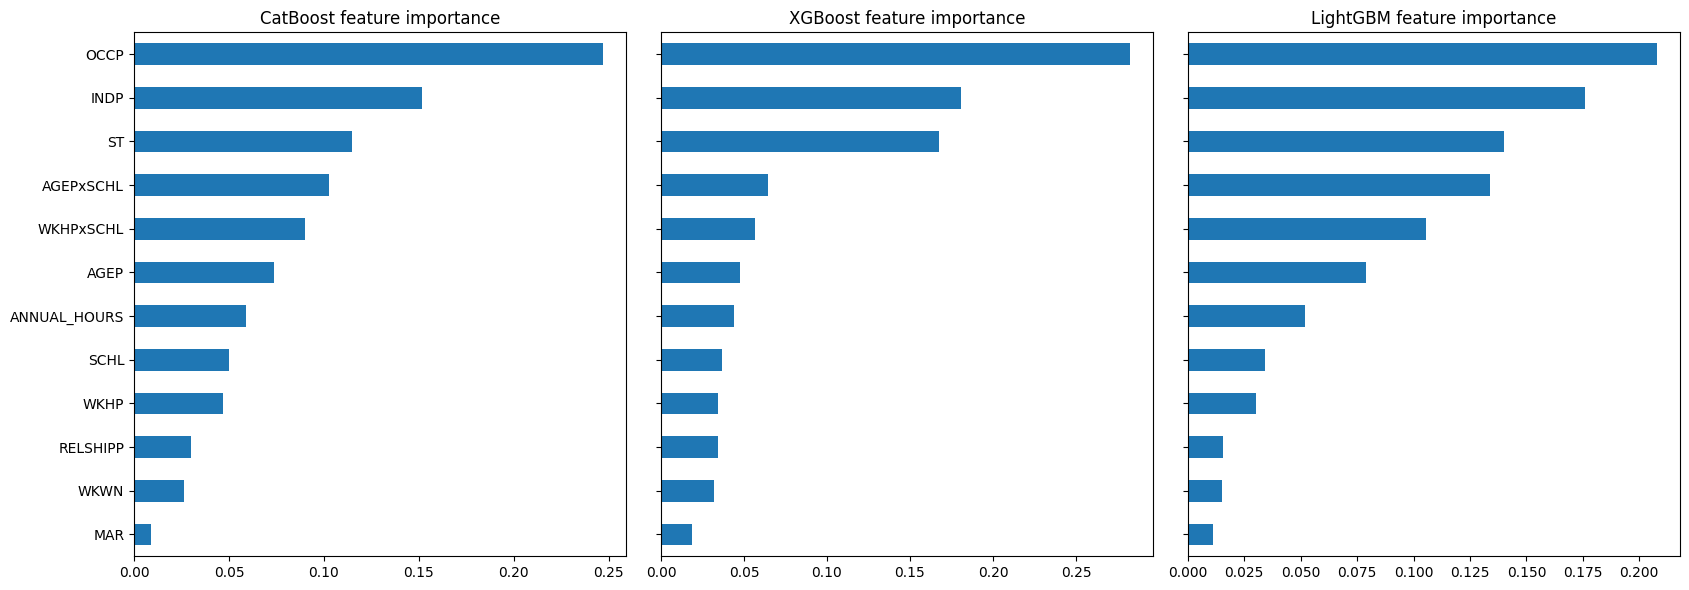

In [23]:
# Feature importance per model (normalised to sum=1 so the three are comparable).
fig, ax = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
for a, (name, (m, _, _)) in zip(ax, MODELS.items()):
    imp = pd.Series(m.get_feature_importance() if name == "CatBoost"
                    else m.feature_importances_, index=list(X_train.columns))
    (imp / imp.sum()).sort_values().plot(kind="barh", ax=a)
    a.set_title(f"{name} feature importance")
plt.tight_layout(); plt.show()

## Stage 12 — Model Saving & Inference

Persist **all three** fitted models plus the shared preprocessing metadata (feature list, categorical columns, target transform, dollar scale) so inference reproduces the exact pipeline. The best model by Test R² is used for the sanity-check prediction.

In [24]:
import joblib

best_name = results_df.iloc[0]["Algorithm"]
bundle = {
    "models": {n: t[0] for n, t in MODELS.items()},
    "best_model": best_name,
    "features": list(X_train.columns),
    "cat_features": CAT_FEATURES,
    "target": TARGET_COLUMN,
    "target_transform": "log1p / expm1",
    "wagp_to_dollars": WAGP_TO_DOLLARS,
    "generated_features": GENERATED_COLS,
    "survey_year": "2024",
    "results": results_df,
}
joblib.dump(bundle, "acs2024_income_models.pkl")
print("Saved acs2024_income_models.pkl | best model:", best_name)

# Reload and predict on a sample with the best model (invert log1p, x1e6 -> dollars).
loaded = joblib.load("acs2024_income_models.pkl")
m, X_tr, X_te = MODELS[loaded["best_model"]]
scale = loaded["wagp_to_dollars"]
sample_pred = np.expm1(m.predict(X_te[:5])) * scale
print("\nGround-truth WAGP:", [f"${v:,.0f}" for v in y_test_raw.values[:5] * scale])
print("Predicted   WAGP:", [f"${v:,.0f}" for v in sample_pred])

Saved acs2024_income_models.pkl | best model: LightGBM

Ground-truth WAGP: ['$76,144', '$610,165', '$254', '$60,915', '$17,259']
Predicted   WAGP: ['$151,649', '$234,142', '$127', '$53,341', '$22,576']


---
## Experiment Log

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|
| Catboost | Feature Gen w/ Select K-Best + Log-on-Target | 28,299.89 | 58,953.75 | 0.51 | 28,966.74 | 60,025.18 | 0.47 |
| XGBoost | Feature Gen w/ Select K-Best + Log-on-Target | 26,186.46 | 54,322.86 | 0.58 | 28,550.22 | 59,295.54 | 0.49 |
| LightGBM | Feature Gen w/ Select K-Best + Log-on-Target | 26,467.84 | 54,269.41 | 0.58 | 28,634.62 | 59,237.01 | 0.49 |

> Rows are produced live by **Stage 11** (`results_df`) on a top-to-bottom run; values above are from the saved execution (CatBoost best_iter 1439, XGBoost 106, LightGBM 329).

**Compare against** the `new_dataset.csv` baselines (Test R² ≈ 0.30) to quantify how much the richer 2024 features + clean population helped.

*Notebook scaffold generated from `ML_Model_Building_Template.md`, wired to `acs2024_income.csv`.*